In [20]:
# final_optimized_qc.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)
# from qiskit.visualization import plot_histogram, plot_distribution
# plot_distribution(final_counts, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from scipy.special import rel_entr # For KL divergence calculation
import itertools

def create_initial_circuit(state_vec_probs):
    """
    Creates a quantum circuit initialized to a given state vector.
    Args:
        state_vec_probs (list or np.array): The amplitudes of the state vector.
                                            Must be normalized and have a length of 2^num_qubits.
    Returns:
        QuantumCircuit: The circuit initialized to the specified state.
    """
    num_qubits = int(np.log2(len(state_vec_probs)))
    if not np.isclose(2**num_qubits, len(state_vec_probs)):
        raise ValueError("Length of state_vec_probs must be a power of 2.")

    qr = QuantumRegister(num_qubits, name='q')
    circuit = QuantumCircuit(qr)
    initial_state_instruction = Initialize(state_vec_probs)
    circuit.append(initial_state_instruction, qr)
    return circuit

def concatenate_circuits_with_separate_measurements(circ1: QuantumCircuit, circ2: QuantumCircuit) -> QuantumCircuit:
    """
    Concatenates two QuantumCircuit objects onto disjoint sets of qubits
    within a larger circuit and adds separate classical registers for measurement
    of each original circuit's qubits.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.

    Returns:
        QuantumCircuit: A new circuit combining circ1 and circ2 on separate
                        qubits, with two distinct classical registers for measurements.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    qr_all = QuantumRegister(num_total_qubits, name='q')
    cr_measure1 = ClassicalRegister(ng_circ1, name='c_measure1')
    cr_measure2 = ClassicalRegister(ng_circ2, name='c_measure2')

    circ_all = QuantumCircuit(qr_all, cr_measure1, cr_measure2)

    # Compose circ1 onto the first set of qubits
    circ_all.compose(circ1, qubits=range(ng_circ1), inplace=True)

    # Compose circ2 onto the next set of qubits
    circ_all.compose(circ2, qubits=range(ng_circ1, num_total_qubits), inplace=True)

    return circ_all

def add_cnots_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    global_cnot_configurations: list[tuple[int, int]]
) -> QuantumCircuit:
    """
    Applies a specified list of CNOT gates (using global qubit indices)
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        global_cnot_configurations (list[tuple[int, int]]): A list of tuples, where each tuple
                                                      (global_control_idx, global_target_idx)
                                                      specifies a CNOT gate using global qubit indices.

    Returns:
        QuantumCircuit: A new circuit with the specified CNOTs and measurements added.
    """
    circuit_with_cnots = base_circuit.copy()

    qr_all = circuit_with_cnots.qregs[0]
    cr_measure1 = circuit_with_cnots.cregs[0]
    cr_measure2 = circuit_with_cnots.cregs[1]

    for control_q, target_q in global_cnot_configurations:
        # Add checks to ensure indices are valid within the combined circuit
        if not (0 <= control_q < circuit_with_cnots.num_qubits and
                0 <= target_q < circuit_with_cnots.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CNOT indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")

        circuit_with_cnots.cx(qr_all[control_q], qr_all[target_q])

    # Add measurements after all CNOTs are applied
    circuit_with_cnots.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_cnots.measure(qr_all[circ1_num_qubits:circuit_with_cnots.num_qubits], cr_measure2)

    return circuit_with_cnots

def get_probability_distribution(counts: dict, num_bits: int, total_shots: int) -> dict:
    """
    Converts a counts dictionary (e.g., {'00': 500, '11': 500}) into
    a probability distribution (e.g., {'00': 0.5, '11': 0.5}).
    Ensures all 2^num_bits outcomes are represented, even if count is 0.
    """
    prob_dist = {}
    for i in range(2**num_bits):
        bitstring = bin(i)[2:].zfill(num_bits)
        prob_dist[bitstring] = counts.get(bitstring, 0) / total_shots
    return prob_dist

def calculate_kl_divergence(p_dist: dict, q_dist: dict, epsilon=1e-9) -> float:
    """
    Calculates the Kullback-Leibler divergence D_KL(P || Q).
    P is the observed distribution, Q is the target distribution.
    Args:
        p_dist (dict): Observed probability distribution (e.g., from simulation).
        q_dist (dict): Target probability distribution.
        epsilon (float): A small value used to handle zero probabilities,
                         to avoid log(0) and division by zero.
    Returns:
        float: The KL divergence.
    """
    kl_div = 0.0

    # Get all possible outcomes from the union of keys to ensure comprehensive check.
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0) # Observed probability for this outcome
        q_val = q_dist.get(key, 0.0) # Target probability for this outcome

        if p_val > 0: # Only sum if the observed probability is non-zero
            if q_val == 0:
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)

    return kl_div

def score_circuit_kl_divergences(
    circuit_to_evaluate: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Evaluates a Qiskit circuit by simulating it and calculates KL divergences
    against provided target probability distributions derived from specific
    state vectors.

    Args:
        circuit_to_evaluate (QuantumCircuit): The Qiskit QuantumCircuit to simulate.
                                              This circuit should already have the
                                              desired CNOT configurations and measurements
                                              applied, and classical registers named
                                              'c_measure1' and 'c_measure2'.
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (kl_div1, kl_div2), which are the KL divergence
               values for c_measure1 and c_measure2 respectively.
               Returns (None, None) if an error occurs during simulation or result retrieval.
    """
    # Determine number of qubits for target distributions from the length of state vectors
    num_qubits_target1 = int(np.log2(len(state_vec_probs_target1)))
    num_qubits_target2 = int(np.log2(len(state_vec_probs_target2)))

    # 2. Define target states (convert amplitudes to probability distributions)
    prob_dist_target1 = {bin(i)[2:].zfill(num_qubits_target1): np.abs(state_vec_probs_target1[i])**2
                         for i in range(2**num_qubits_target1)}

    prob_dist_target2 = {bin(i)[2:].zfill(num_qubits_target2): np.abs(state_vec_probs_target2[i])**2
                         for i in range(2**num_qubits_target2)}

    # 5. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit_to_evaluate)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # Access results using the classical register names
    try:
        result = job.result()[0]
        counts_measure1 = result.data.c_measure1.get_counts()
        counts_measure2 = result.data.c_measure2.get_counts()
    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2'.")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred during simulation or result retrieval: {e}")
        return None, None

    # 6. Convert raw counts to probability distributions
    num_bits_cr1 = circuit_to_evaluate.cregs[0].size if circuit_to_evaluate.cregs else 0
    num_bits_cr2 = circuit_to_evaluate.cregs[1].size if len(circuit_to_evaluate.cregs) > 1 else 0

    prob_dist_sim1 = get_probability_distribution(counts_measure1, num_bits_cr1, nshots)
    prob_dist_sim2 = get_probability_distribution(counts_measure2, num_bits_cr2, nshots)

    # 7. Calculate KL Divergence
    kl_div1 = calculate_kl_divergence(prob_dist_sim1, prob_dist_target1)
    kl_div2 = calculate_kl_divergence(prob_dist_sim2, prob_dist_target2)

    return kl_div1, kl_div2

def find_best_cnot_sequence(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Performs a greedy search to find a sequence of CNOT gates between two
    quantum circuit "chunks" (circ1 and circ2) that iteratively improves
    the combined KL divergence against target state vectors.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting CNOT Sequence Optimization (Total Qubits: {num_total_qubits}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Greedy search for the best sequence of CNOTs
    iteration_count = 0
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = min_kl_sum # Start comparison from the best found so far

        print(f"\n--- Iteration {iteration_count}: Current Best KL Sum = {min_kl_sum:.6f} ---")

        for candidate_cnot in all_possible_single_cnots:
            # Only consider CNOTs not already in the current best sequence
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]

                # Create circuit with current best sequence + candidate CNOT
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                    temp_base_circuit, ng_circ1, temp_cnot_sequence
                )

                kl_div1, kl_div2 = score_circuit_kl_divergences(
                    temp_circuit_with_cnots,
                    state_vec_probs_target1,
                    state_vec_probs_target2,
                    nshots
                )

                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    # print(f"  Testing CNOT {candidate_cnot} with existing sequence: KL Sum {current_kl_sum:.6f}") # For debugging

                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True

        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            min_kl_sum = current_iteration_min_kl_sum
            print(f"\nIteration {iteration_count} improved! Added CNOT: {current_iteration_best_cnot}")
            print(f"Current best CNOT sequence: {best_cnot_sequence}")
            print(f"Current minimum combined KL Divergence: {min_kl_sum:.6f}")
        else:
            print(f"\nIteration {iteration_count}: No further single CNOT additions improved the KL divergence.")
            break # No improvement in this iteration, stop

    return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_brute_force(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1, # Limit the depth for practical reasons
    nshots: int = 1000
):
    """
    Performs a brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates all possible permutations of CNOTs and returns the sequence
    that yields the lowest combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Brute-force search for the best sequence of CNOTs up to max_cnot_depth
    for num_cnots in range(1, max_cnot_depth + 1):
        print(f"\n--- Testing combinations with {num_cnots} CNOTs ---")
        # Use permutations to account for order, as CNOT order matters
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            temp_cnot_sequence = list(cnot_combination)

            # Create circuit with current CNOT sequence
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                temp_base_circuit, ng_circ1, temp_cnot_sequence
            )

            kl_div1, kl_div2 = score_circuit_kl_divergences(
                temp_circuit_with_cnots,
                state_vec_probs_target1,
                state_vec_probs_target2,
                nshots
            )

            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                # print(f"  Testing CNOT sequence {temp_cnot_sequence}: KL Sum {current_kl_sum:.6f}") # For debugging brute force

                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")

    # If no CNOT sequence improved over the baseline, return the baseline results
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum


def plot_measurement_histograms(circuit: QuantumCircuit, nshots: int = 1000, title_prefix: str = "", figure_save_name: str = None):
    """
    Simulates the given circuit and plots histograms for its classical registers
    (c_measure1 and c_measure2) side-by-side. The plots are displayed interactively
    and can optionally be saved to a file.

    Args:
        circuit (QuantumCircuit): The Qiskit QuantumCircuit to simulate and plot.
                                  It must have classical registers named 'c_measure1' and 'c_measure2'.
        nshots (int): The number of shots for the simulation. Defaults to 1000.
        title_prefix (str): A prefix to add to the overall figure title (e.g., "Final Circuit").
        figure_save_name (str, optional): If provided, the figure will be saved to this filename.
                                          Defaults to None (figure only displayed interactively).
    """
    print(f"\n--- Simulating and Plotting Histograms for: {title_prefix} ---")

    # 1. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # 2. Access results and plot histograms
    try:
        result = job.result()[0]
        
        counts_measure1 = None
        counts_measure2 = None

        # Check if classical registers exist and get counts
        if 'c_measure1' in [creg.name for creg in circuit.cregs]:
            counts_measure1 = result.data.c_measure1.get_counts()
            print(f"Counts for c_measure1: {counts_measure1}")
        else:
            print("Warning: Classical register 'c_measure1' not found in circuit. Skipping histogram for c_measure1.")

        if 'c_measure2' in [creg.name for creg in circuit.cregs]:
            counts_measure2 = result.data.c_measure2.get_counts()
            print(f"Counts for c_measure2: {counts_measure2}")
        else:
            print("Warning: Classical register 'c_measure2' not found in circuit. Skipping histogram for c_measure2.")

        # Create a figure with two subplots
        if counts_measure1 is not None or counts_measure2 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 row, 2 columns
            fig.suptitle(f"{title_prefix} - Measurement Counts ({nshots} shots)", fontsize=16)

            if counts_measure1 is not None:
                plot_histogram(counts_measure1, ax=axes[0], title="c_measure1")
            else:
                axes[0].set_title("c_measure1 (Not Found)")
                axes[0].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

            if counts_measure2 is not None:
                plot_histogram(counts_measure2, ax=axes[1], title="c_measure2")
            else:
                axes[1].set_title("c_measure2 (Not Found)")
                axes[1].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show() # Display the figure

            if figure_save_name:
                try:
                    fig.savefig(figure_save_name)
                    print(f"Histogram figure saved to {figure_save_name}")
                except Exception as save_e:
                    print(f"Error saving figure to {figure_save_name}: {save_e}")
                finally:
                    plt.close(fig) # Close the figure after showing/saving to free memory
        else:
            print("No classical register data available to plot histograms.")

    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2' and measurements are applied.")
    except Exception as e:
        print(f"An unexpected error occurred during simulation or plotting: {e}")

In [ ]:
# 1. Define initial circuits for concatenation
state_probs_bell = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)] # 2-qubit state
circ_bell = create_initial_circuit(state_vec_probs=state_probs_bell)

state_probs_ghz_ish = [0, 1/np.sqrt(2), 1/np.sqrt(2), 0] # 2-qubit state
circ_ghz_ish = create_initial_circuit(state_vec_probs=state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])
state_probs_target2_amplitudes = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

# --- Demonstrate Greedy Search ---
print("\n" + "="*40)
print("--- Running Greedy Search ---")
print("="*40)
best_cnot_sequence_greedy, min_kl_greedy = find_best_cnot_sequence(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    nshots=2000
)

print("\n" + "="*40)
if best_cnot_sequence_greedy:
    print("Greedy Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence_greedy:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_greedy:.6f}")

    # Construct and draw the final best circuit from greedy search
    ng_circ1_for_greedy = circ_bell.num_qubits
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, ng_circ1_for_greedy, best_cnot_sequence_greedy
    )
    print("\n--- Final Optimized Circuit (Greedy) ---")
    print(final_best_circuit_greedy.draw('text'))
else:
    print("Greedy Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_greedy:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_greedy.draw('text'))
print("="*40 + "\n")



--- Running Greedy Search ---

--- Starting CNOT Sequence Optimization (Total Qubits: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.061908
Initial best KL sum: 40.061908 (from baseline)

--- Iteration 1: Current Best KL Sum = 40.061908 ---

Iteration 1 improved! Added CNOT: (2, 0)
Current best CNOT sequence: [(2, 0)]
Current minimum combined KL Divergence: 29.262714

--- Iteration 2: Current Best KL Sum = 29.262714 ---

Iteration 2 improved! Added CNOT: (1, 2)
Current best CNOT sequence: [(2, 0), (1, 2)]
Current minimum combined KL Divergence: 18.137348

--- Iteration 3: Current Best KL Sum = 18.137348 ---

Iteration 3 improved! Added CNOT: (3, 1)
Current best CNOT sequence: [(2, 0), (1, 2), (3, 1)]
Current minimum combined KL Divergence: 9.222522

--- Iteration 4: Current Best KL Sum = 9.222522 ---

Iteration 4 improved! Added CNOT: (1, 3)
Current best CNOT sequence: [(2, 0), (1, 2), (3, 1), (1, 3)]
Current minimum combined KL Di

In [ ]:

# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 4 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=2000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.060865
Initial best KL sum: 40.060865 (from baseline)

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 29.142446
  --> New best sequence found: [(0, 3)] with KL Sum: 29.023073

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 18.874906
  --> New best sequence found: [(0, 2), (2, 1)] with KL Sum: 18.786223
  --> New best sequence found: [(0, 2), (3, 1)] with KL Sum: 18.574285
  --> New best sequence found: [(0, 3), (2, 0)] with KL Sum: 18.225132
  --> New best sequence found: [(1, 2), (3, 0)] with KL Sum: 18.045080

--- Testing combinations with 3 CNOTs ---
  --> New best sequence found: [(2, 0), (0, 2), (3, 0)] with KL Sum: 9.291880
  --> New best sequence found: [(2, 0),

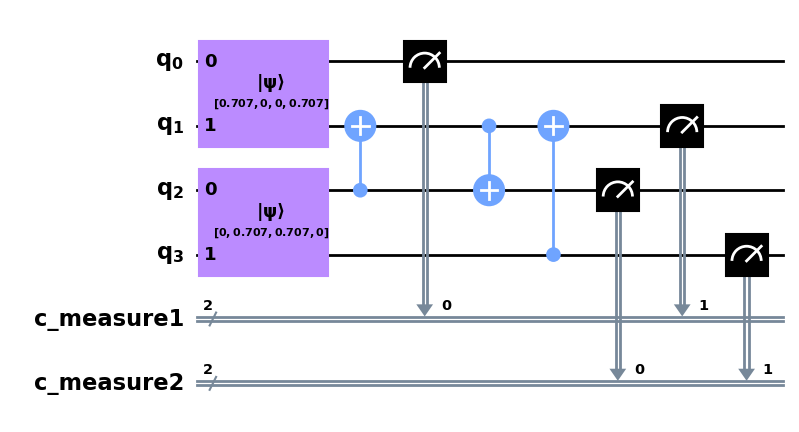

In [42]:
final_best_circuit_greedy.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

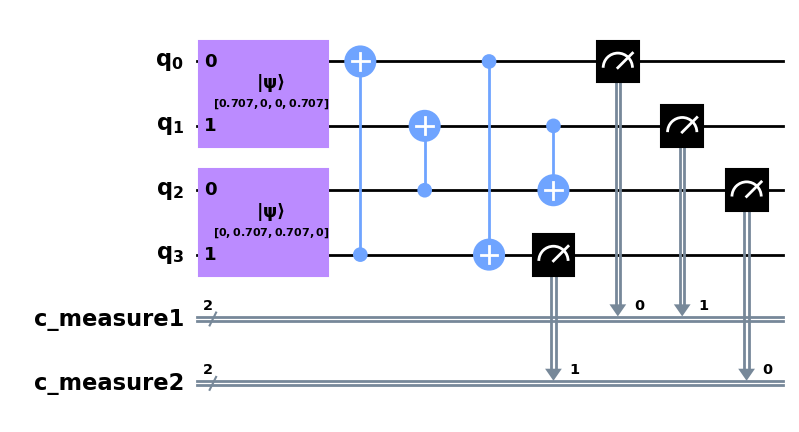

In [43]:
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 995, '10': 1005}
Counts for c_measure2: {'01': 490, '10': 498, '11': 505, '00': 507}


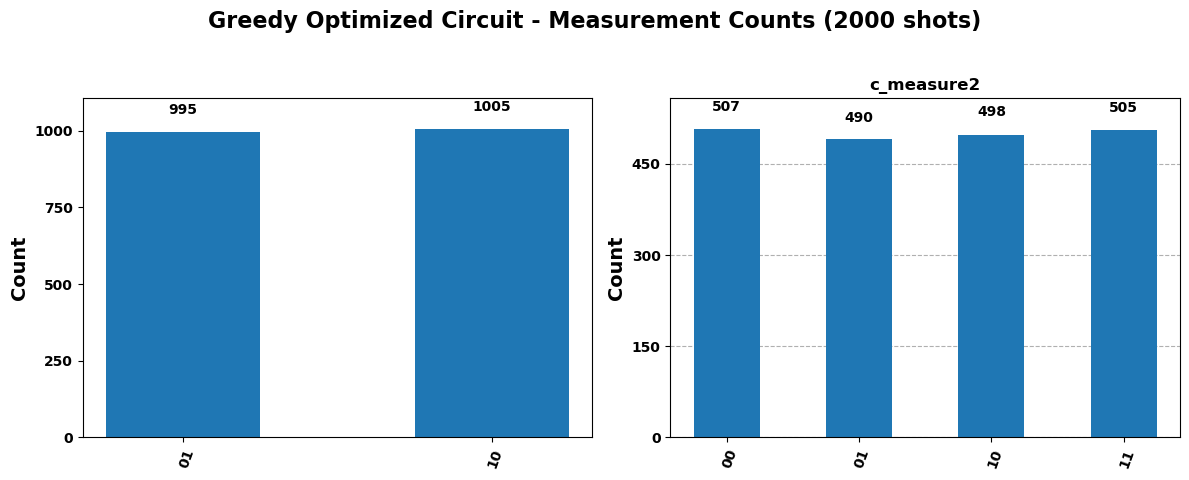

In [48]:
plot_measurement_histograms(final_best_circuit_greedy, nshots=2000, title_prefix="Greedy Optimized Circuit")


--- Simulating and Plotting Histograms for: Brute-Force Optimized Circuit ---
Counts for c_measure1: {'10': 994, '01': 1006}
Counts for c_measure2: {'00': 1031, '11': 969}


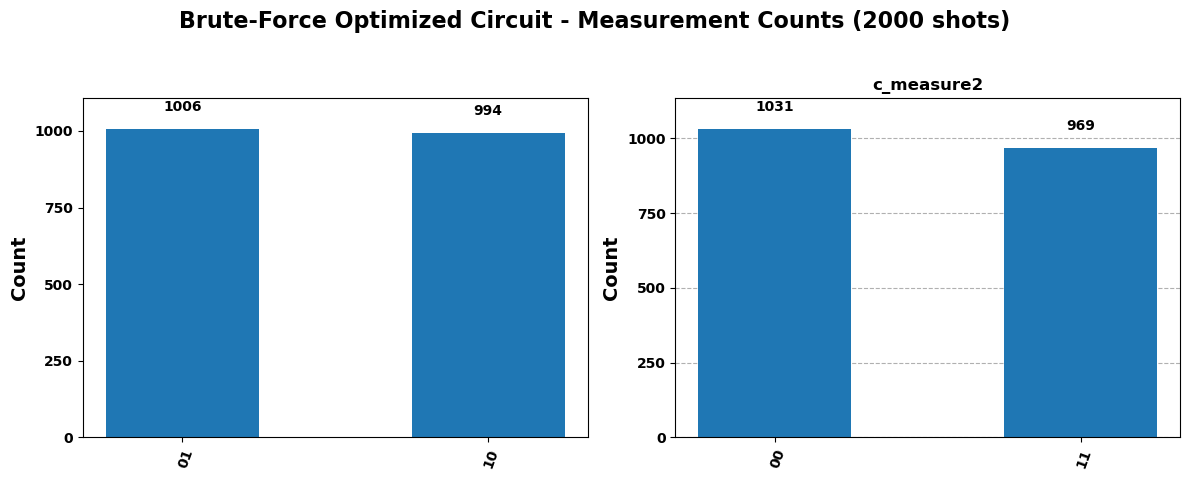

In [49]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=2000, title_prefix="Brute-Force Optimized Circuit")

In [ ]:
# 1. Define initial circuits for concatenation
state_probs_bell = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)] # 2-qubit state
circ_bell = create_initial_circuit(state_vec_probs=state_probs_bell)

state_probs_ghz_ish = [0, 1/np.sqrt(2), 1/np.sqrt(2), 0] # 2-qubit state
circ_ghz_ish = create_initial_circuit(state_vec_probs=state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])
state_probs_target2_amplitudes = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])